# TeleComX — Customer Churn Analysis
## Notebook 3: Exploratory Data Analysis (EDA)
**Analyst:** Adedayo Adeyinka A  
**Date:** June 2026  
**Objective:** Visualize churn patterns to confirm and communicate SQL findings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/telecomx_clean.csv')

# Set visual style for all charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Setup complete. Data loaded:", df.shape)

Setup complete. Data loaded: (7043, 21)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2220\1771546215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette=['#2E86AB', '#E63946'])


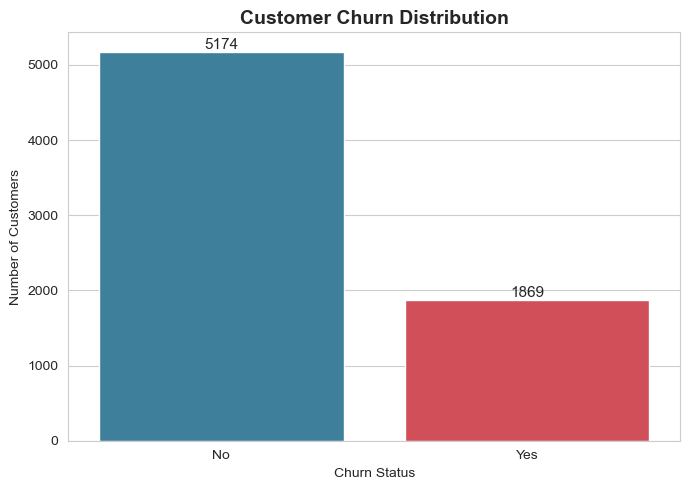

In [2]:
# Chart 1: Overall churn distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Churn', palette=['#2E86AB', '#E63946'])
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../visuals/01_churn_distribution.png', dpi=150)
plt.show()

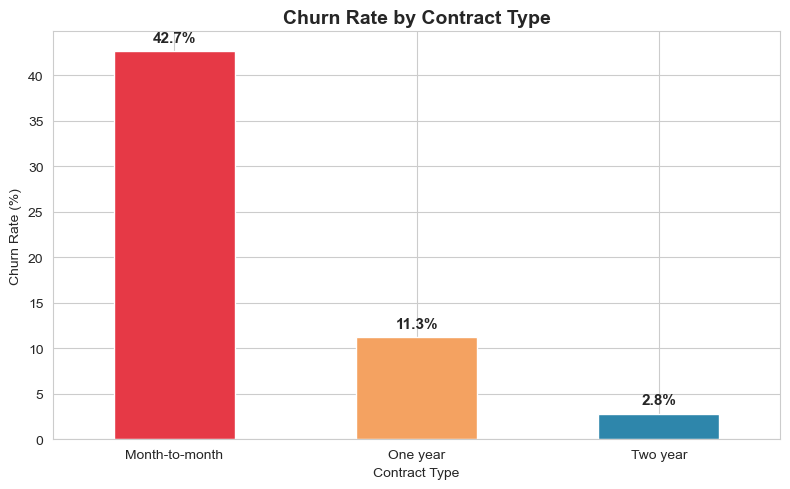

In [3]:
# Chart 2: Churn rate by contract type
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

ax = contract_churn.plot(kind='bar', color=['#E63946', '#F4A261', '#2E86AB'])
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(contract_churn):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/02_churn_by_contract.png', dpi=150)
plt.show()

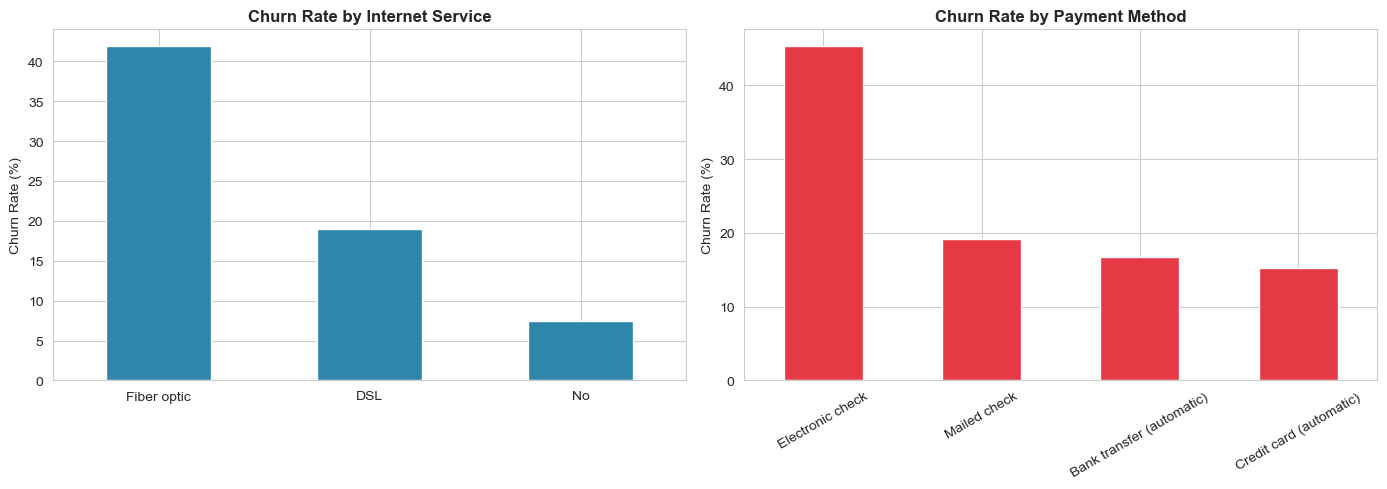

In [4]:
# Chart 3: Two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Internet Service
internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
internet_churn.plot(kind='bar', ax=axes[0], color='#2E86AB')
axes[0].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
payment_churn.plot(kind='bar', ax=axes[1], color='#E63946')
axes[1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../visuals/03_internet_payment_churn.png', dpi=150)
plt.show()

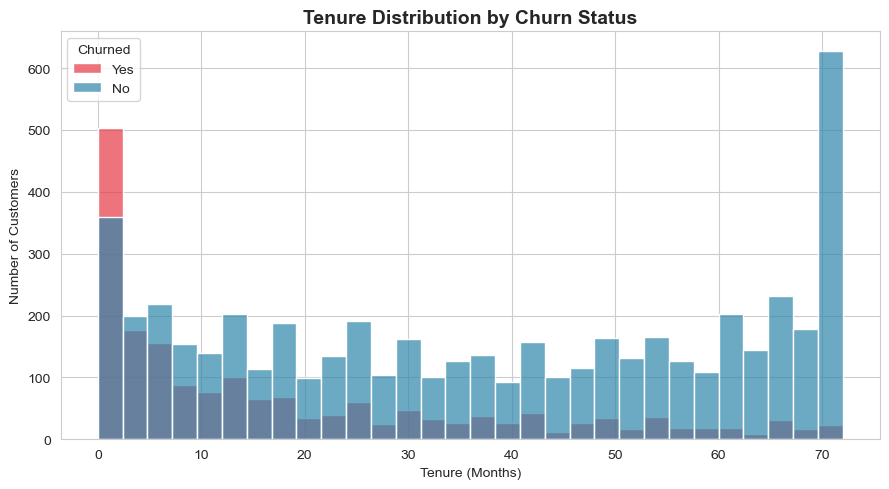

In [5]:
# Chart 4: Tenure distribution - do new customers churn more?
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, 
             palette=['#2E86AB', '#E63946'], alpha=0.7)
plt.title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend(title='Churned', labels=['Yes', 'No'])
plt.tight_layout()
plt.savefig('../visuals/04_tenure_distribution.png', dpi=150)
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2220\2661896880.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',


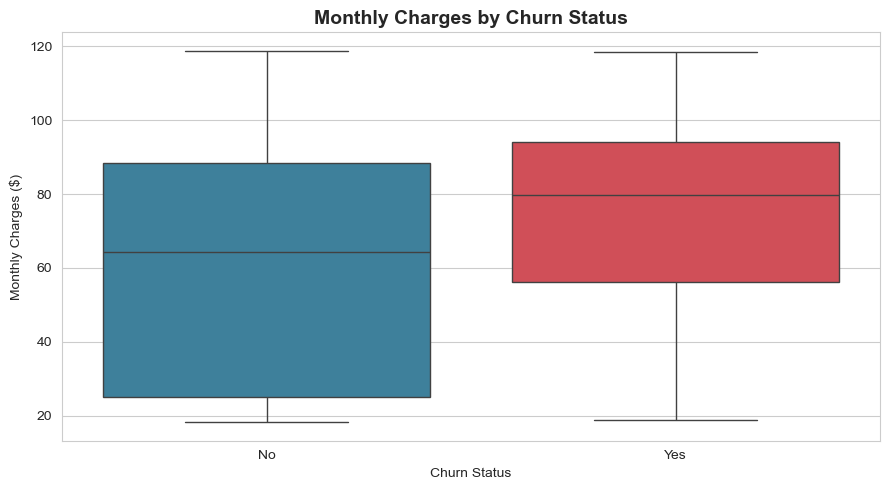

In [6]:
# Chart 5: Monthly charges - do higher paying customers churn more?
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', 
            palette=['#2E86AB', '#E63946'])
plt.title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('../visuals/05_monthly_charges_churn.png', dpi=150)
plt.show()

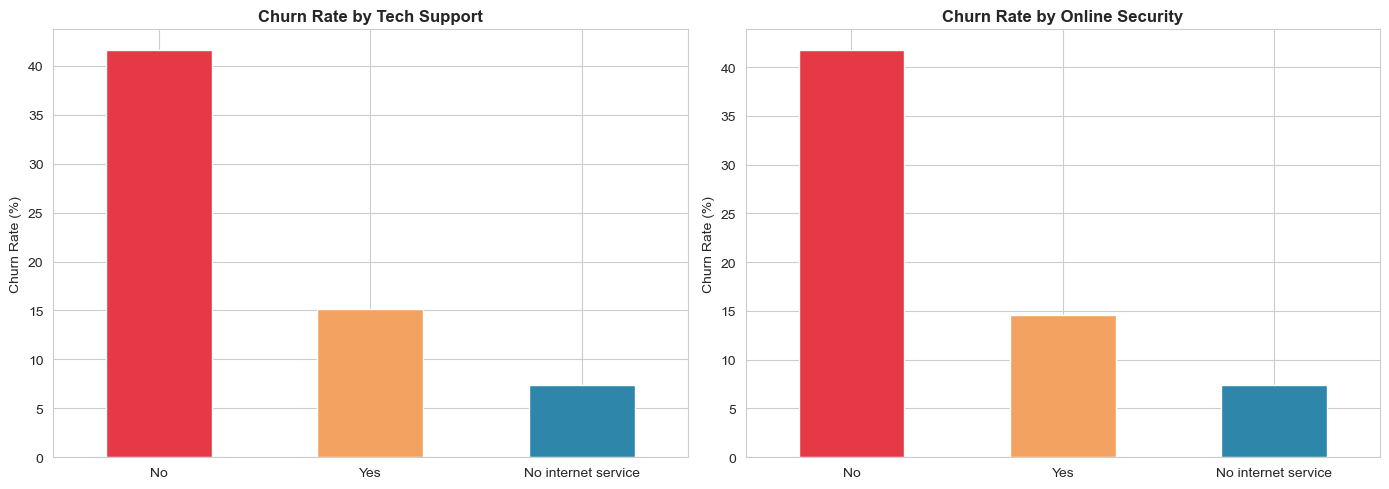

In [7]:
# Chart 6: Do protective services reduce churn?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tech Support
tech_churn = df.groupby('TechSupport')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
tech_churn.plot(kind='bar', ax=axes[0], color=['#E63946', '#F4A261', '#2E86AB'])
axes[0].set_title('Churn Rate by Tech Support', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Online Security
security_churn = df.groupby('OnlineSecurity')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
security_churn.plot(kind='bar', ax=axes[1], color=['#E63946', '#F4A261', '#2E86AB'])
axes[1].set_title('Churn Rate by Online Security', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../visuals/06_techsupport_security_churn.png', dpi=150)
plt.show()

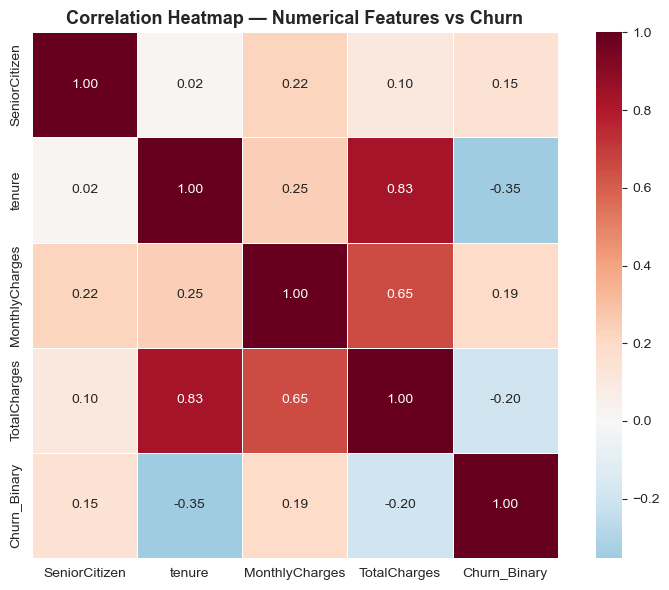

In [8]:
# Chart 7: Correlation heatmap
# First encode Churn as binary (Yes=1, No=0)
df_corr = df.copy()
df_corr['Churn_Binary'] = (df_corr['Churn'] == 'Yes').astype(int)

# Select numerical columns
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']
corr_matrix = df_corr[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features vs Churn', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/07_correlation_heatmap.png', dpi=150)
plt.show()

In [9]:
print("=" * 45)
print("EDA COMPLETE — VISUALS SAVED")
print("=" * 45)
print("01_churn_distribution.png")
print("02_churn_by_contract.png")
print("03_internet_payment_churn.png")
print("04_tenure_distribution.png")
print("05_monthly_charges_churn.png")
print("06_techsupport_security_churn.png")
print("07_correlation_heatmap.png")
print("=" * 45)
print("\nKey EDA Findings:")
print("- Month-to-month contracts: 42.7% churn")
print("- Electronic check payment: 45.3% churn")
print("- Fiber optic internet: 41.9% churn")
print("- New customers (0-12 months): 47.4% churn")
print("- Churned customers pay $13 more/month avg")
print("- Tenure is the strongest churn predictor")

EDA COMPLETE — VISUALS SAVED
01_churn_distribution.png
02_churn_by_contract.png
03_internet_payment_churn.png
04_tenure_distribution.png
05_monthly_charges_churn.png
06_techsupport_security_churn.png
07_correlation_heatmap.png

Key EDA Findings:
- Month-to-month contracts: 42.7% churn
- Electronic check payment: 45.3% churn
- Fiber optic internet: 41.9% churn
- New customers (0-12 months): 47.4% churn
- Churned customers pay $13 more/month avg
- Tenure is the strongest churn predictor
